# Multigrid: correct errors at the scale where they are visible

Why can a coarse grid accelerate the solution of a fine-grid phase problem?

We start with numbers that can be checked by hand, draw the algorithm’s decision, then run the public API on data with known truth. All phase values are in radians unless stated otherwise.

In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
ROOT = Path.cwd().resolve()
if not (ROOT / 'src' / 'parvaneh').is_dir(): ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))
import parvaneh as pv
plt.rcParams.update({'figure.dpi': 115, 'font.size': 10,
                     'axes.spines.top': False, 'axes.spines.right': False})
def W(x): return (np.asarray(x)+np.pi) % (2*np.pi)-np.pi
def table(headers, rows):
    display(Markdown('| '+' | '.join(headers)+' |\n|'+
        '|'.join(['---']*len(headers))+'|\n'+
        '\n'.join('| '+' | '.join(map(str,r))+' |' for r in rows)))
def images(arrays, titles, cmap='viridis'):
    fig,axes=plt.subplots(1,len(arrays),figsize=(4*len(arrays),3.4),constrained_layout=True)
    for ax,a,title in zip(np.atleast_1d(axes),arrays,titles):
        im=ax.imshow(a,cmap=cmap); ax.set(title=title,xlabel='column',ylabel='row')
        fig.colorbar(im,ax=ax,shrink=.75)
    plt.show()
def align(u,t): return u-np.mean(u-t)
def scene():
    y,x=np.mgrid[0:18,0:22]
    truth=.38*x+.22*y+1.4*np.exp(-((x-12)**2+(y-8)**2)/25)
    patch=(x>=8)&(x<=14)&(y>=5)&(y<=12)
    rng=np.random.default_rng(21)
    phase=W(truth+rng.normal(size=truth.shape)*np.where(patch,1.35,.06))
    confidence=np.where(patch,.2,1.)
    return truth,phase,confidence
def report(u,t,w):
    assert u.shape==t.shape and np.isfinite(u).all()
    table(['Quantity','Measured value'],[
        ['Aligned RMSE (rad)',f'{pv.rmse_aligned(u,t):.6f}'],
        ['Raw max wrapped difference from input (rad)',f'{np.max(np.abs(W(u-w))):.6f}']])
    images([align(u,t),align(u,t)-t],['Aligned reconstruction (rad)','Error against truth (rad)'])

## 1 · Work through the model

For $Au=b$ with $A=D^TQD$, define residual $r=b-Au$. If the error is
$e=u_* -u$, then $Ae=r$. This is the correction equation.

1. Relax on the fine grid to reduce rapidly varying error.
2. Restrict $r$ to a coarser grid.
3. Approximately solve the coarse error equation.
4. Prolong the correction and add it to the fine estimate.
5. Relax again; repeat these V-cycles until the relative residual is small.

A slowly varying error needs many local sweeps on a fine grid. On a coarse grid
the same shape spans fewer nodes, so local relaxation can address it more quickly.

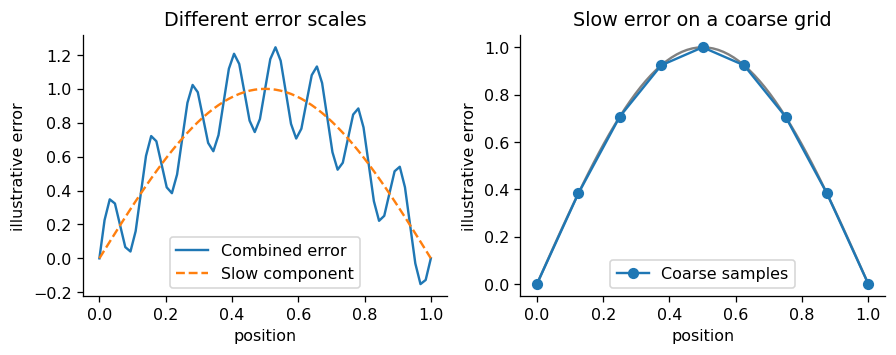

In [2]:
x=np.linspace(0,1,65); smooth=np.sin(np.pi*x); rapid=.25*np.sin(16*np.pi*x)
fig,axes=plt.subplots(1,2,figsize=(9,3))
axes[0].plot(x,smooth+rapid,label='Combined error'); axes[0].plot(x,smooth,'--',label='Slow component')
axes[1].plot(x,smooth,color='gray'); axes[1].plot(x[::8],smooth[::8],'o-',label='Coarse samples')
axes[0].set_title('Different error scales'); axes[1].set_title('Slow error on a coarse grid')
for ax in axes: ax.set(xlabel='position',ylabel='illustrative error'); ax.legend()
plt.show()

## 2 · Read the calculation

This is an illustration of error scales, not a record of solver iterations.
Next we measure actual solves with different cycle budgets. Multigrid changes
how the linear equations are solved; it does not change least squares into an
integer-label method or remove its offset ambiguity.

## 3 · Run the implementation

The seed and input sizes below are fixed. A low objective or a converged solver means the chosen mathematical problem was solved; it does not prove the physical phase was recovered.

MultigridInfo(backend='numpy', levels=5, coarsest=(2, 2), cycles=12, sweeps=792, relative_residual=2.930724816244728e-09, converged=True, seconds=0.10094398699584417, residuals=(0.0773357980301793, 0.013529955800342443, 0.0027702100768335716, 0.0005840621337253267, 0.00012462451798254368, 2.680460557558588e-05, 5.801951576558737e-06, 1.2624076542730123e-06, 2.7584625109533057e-07, 6.048233839873452e-08, 1.3298559384467362e-08, 2.930724816244728e-09))


| Quantity | Measured value |
|---|---|
| Aligned RMSE (rad) | 0.000000 |
| Raw max wrapped difference from input (rad) | 0.144497 |

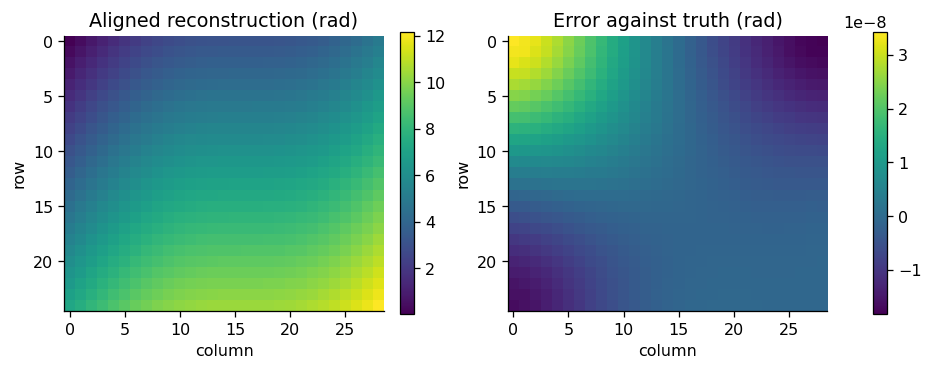

In [3]:
y,x=np.mgrid[0:25,0:29]; truth=.2*x+.3*y+np.sin(x/5)
phase=W(truth)
u,info=pv.multigrid_unwrap(phase,max_cycles=80,tol=1e-8,return_info=True)
print(info); report(u,truth,phase)

## 4 · Change one choice and measure its effect

This controlled experiment changes a solver setting, data condition, or reference calculation. Compare the measured values before drawing a conclusion.

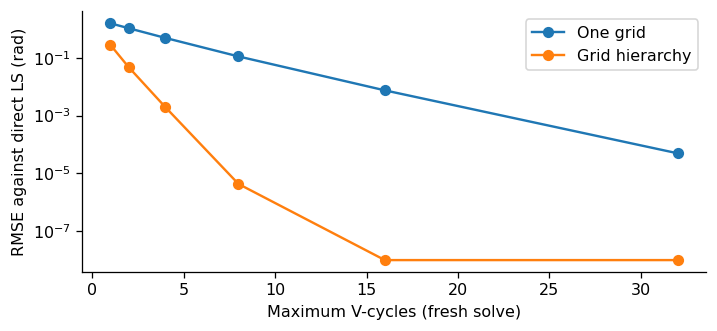

In [4]:
budgets=[1,2,4,8,16,32]; reference=pv.unwrap(phase)
fig,ax=plt.subplots(figsize=(7,3))
for levels,label in [(1,'One grid'),(None,'Grid hierarchy')]:
    errors=[]
    for budget in budgets:
        value=pv.multigrid_unwrap(phase,levels=levels,max_cycles=budget)
        errors.append(max(pv.rmse_aligned(value,reference),1e-15))
    ax.semilogy(budgets,errors,'o-',label=label)
ax.set(xlabel='Maximum V-cycles (fresh solve)',ylabel='RMSE against direct LS (rad)'); ax.legend(); plt.show()

## 5 · Interpretation and limits

These points are fresh solves with increasing budgets, not timing measurements.
Inspect the convergence report: reaching `max_cycles` is not convergence.
Strong weight contrasts may stall or destabilize the hierarchy. The method
supports N-D arrays, but coarse levels stop when axes become too short.
Masked samples do not automatically become NaN; callers must reapply their mask.

## Continue exploring

Rerun with another seed or a larger phase step. Predict which assumption fails first, then inspect the result and report. The method’s output convention and masks matter as much as its RMSE.

Implementation: [`multigrid.py`](../src/parvaneh/multigrid.py). See the [API reference](../docs/api.md), [notebook index](../docs/notebooks.md), [mathematical derivations](../docs/mathematics.md), and [bibliography](../docs/references.md) for further reading. These examples describe the current implementation, including its limitations; they are not claims of numerical identity with external software.